# 🖴 HDD Recovery Optimization: Hybrid DP vs Greedy Nearest Neighbor

**Eksperimen Komputasi — Simulasi Pemulihan Sektor Rusak pada Hard Disk Drive (HDD)**

---

## Latar Belakang

Hard Disk Drive (HDD) menyimpan data dalam satuan terkecil yang disebut **sektor** (512 byte per sektor). Seiring waktu, sektor-sektor tersebut dapat mengalami kerusakan fisik atau magnetik — yang dikenal sebagai **bad sector**. Proses *recovery* atau pemindaian ulang sektor rusak membutuhkan waktu yang signifikan, terutama karena setiap bad sector dikenai **penalti waktu retry** saat dibaca.

Masalah inti yang diangkat dalam eksperimen ini adalah:

> **Dalam urutan apa sektor-sektor target harus dikunjungi oleh head HDD agar total waktu pemulihan seminimal mungkin?**

Ini adalah varian dari **Travelling Salesman Problem (TSP)** yang diterapkan pada ruang linear satu dimensi (LBA — Logical Block Address).

---

## Pendekatan yang Dibandingkan

| Algoritma | Strategi | Kompleksitas |
|-----------|----------|--------------|
| **Hybrid DP (Held-Karp)** | Dynamic Programming bitmask — menjamin solusi optimal | O(k² × 2^k) |
| **Greedy Nearest Neighbor** | Selalu mengunjungi sektor terdekat berikutnya | O(k²) |

Di mana **k** adalah jumlah sektor target yang ingin direcovery.

---

## Struktur Notebook

| Bagian | Konten |
|--------|--------|
| **Bagian 1** | Library, Model HDD (LOGI), dan Algoritma Dijkstra |
| **Bagian 2** | DP TSP (Held-Karp) dan Greedy Nearest Neighbor |
| **Bagian 3** | 4 Eksperimen utama + penyimpanan CSV |
| **Bagian 4** | Visualisasi hasil (6 plot) |

---


## 📦 Bagian 1 — Library, Model HDD (LOGI), dan Dijkstra

### 1.1 Import Library

Notebook ini menggunakan library standar Python:
- `heapq` — priority queue untuk Dijkstra
- `dataclasses` — struktur data konfigurasi HDD yang bersih
- `numpy` & `matplotlib` — komputasi numerik dan visualisasi


In [1]:
# ================================================================
# BAGIAN 1: Import Library + hdd_logi + dijkstra
# ================================================================

import time, math, random, csv, os, heapq
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib
from dataclasses import dataclass, field
from typing import List, Tuple, Set
from IPython.display import display

os.makedirs('results/figures', exist_ok=True)
print('✅ Library siap!')
print(f'   NumPy     : {np.__version__}')
print(f'   Matplotlib: {matplotlib.__version__}')

✅ Library siap!
   NumPy     : 2.0.2
   Matplotlib: 3.10.0


### 1.2 Model HDD: LOGI (*Logistic Infection Model*)

Model **LOGI** mensimulasikan pola kemunculan bad sector pada HDD secara realistis. Tidak seperti distribusi acak murni, bad sector di dunia nyata cenderung **membentuk klaster** — kerusakan di satu sektor berpotensi menyebar ke sektor-sektor tetangganya.

#### Komponen Utama

**`HDDConfig`** — Parameter simulasi yang bisa dikustomisasi:

| Parameter | Default | Keterangan |
|-----------|---------|-----------|
| `num_sectors` | 10.000 | Jumlah total sektor LBA |
| `bad_ratio` | 0.05 | Persentase sektor rusak (0.0–1.0) |
| `cluster_prob` | 0.75 | Probabilitas penyebaran bad sector ke tetangga |
| `read_speed` | 150 MB/s | Kecepatan baca HDD (tipikal 7200 RPM) |
| `scanner_throughput` | 200 MB/s | Throughput scanner |
| `retry_time` | 8.0 detik | Penalti waktu per bad sector |

**`generate_logi(config)`** — Algoritma BFS untuk membangkitkan klaster bad sector:
1. Tanamkan beberapa *seed* awal secara acak
2. Dari setiap seed, sebarkan ke sektor tetangga (LBA±1) dengan probabilitas `cluster_prob`
3. Ulangi hingga jumlah bad sector mencapai target

**Fungsi pendukung:**
- `compute_edge_weight(src, dst, hdd)` — Hitung bobot edge: `SECTOR_SIZE_MB / speed + penalty(dst)`
- `build_adjacency(hdd)` — Adjacency list graf linear HDD (bidirectional, LBA±1)


In [2]:
# ================================================================
# MODUL: hdd_logi
# ================================================================

SECTOR_SIZE_BYTES = 512
SECTOR_SIZE_MB    = SECTOR_SIZE_BYTES / (1024 * 1024)


@dataclass
class HDDConfig:
    num_sectors:        int   = 10_000   # ← Ukuran HDD (jumlah sektor)
    bad_ratio:          float = 0.05     # ← Persentase bad sector (0.0–1.0)
    cluster_prob:       float = 0.75     # ← Tingkat pengelompokan bad sector
    read_speed:         float = 150.0    # ← Kecepatan baca MB/s
    scanner_throughput: float = 200.0    # ← Throughput scanner MB/s
    retry_time:         float = 8.0      # ← Penalti per bad sector (detik)
    seed:               int   = 42       # ← Random seed


@dataclass
class HDDState:
    """Hasil simulasi: status tiap sektor dan metadata."""
    config:        HDDConfig
    bad_sectors:   Set[int]  = field(default_factory=set)
    sector_status: List[int] = field(default_factory=list)

    def is_bad(self, lba: int) -> bool:
        return lba in self.bad_sectors

    def cluster_info(self) -> dict:
        clusters, cur = [], []
        for i, s in enumerate(self.sector_status):
            if s == 1:
                cur.append(i)
            elif cur:
                clusters.append(cur)
                cur = []
        if cur:
            clusters.append(cur)
        sizes = [len(c) for c in clusters]
        return {
            'num_clusters':     len(clusters),
            'avg_cluster_size': np.mean(sizes) if sizes else 0,
            'max_cluster_size': max(sizes) if sizes else 0,
            'total_bad':        len(self.bad_sectors),
            'bad_ratio_actual': len(self.bad_sectors) / len(self.sector_status),
        }


def generate_logi(config: HDDConfig) -> HDDState:
    """
    Bangkitkan pola bad sector menggunakan model LOGI.
    Algoritma BFS dengan probabilitas propagasi ke tetangga.
    Kompleksitas: O(N) rata-rata.
    """
    rng = random.Random(config.seed)
    np.random.seed(config.seed)
    N       = config.num_sectors
    target  = int(N * config.bad_ratio)
    status  = [0] * N
    bad_set = set()
    queue   = []

    def plant_seed():
        lba = rng.randint(0, N - 1)
        if status[lba] == 0:
            status[lba] = 1
            bad_set.add(lba)
            queue.append(lba)

    for _ in range(max(1, target // 20)):
        plant_seed()

    idx = 0
    while len(bad_set) < target:
        if idx >= len(queue):
            plant_seed()
            if idx >= len(queue):
                break
        lba = queue[idx]
        idx += 1
        for nb in [lba - 1, lba + 1]:
            if 0 <= nb < N and status[nb] == 0:
                if rng.random() < config.cluster_prob:
                    status[nb] = 1
                    bad_set.add(nb)
                    queue.append(nb)
                    if len(bad_set) >= target:
                        break

    return HDDState(config=config, bad_sectors=bad_set, sector_status=status)


def compute_edge_weight(src: int, dst: int, hdd: HDDState) -> float:
    """
    Hitung bobot edge antar sektor.
    w = SECTOR_SIZE_MB / effective_speed + penalty(dst)
    """
    cfg   = hdd.config
    speed = min(cfg.read_speed, cfg.scanner_throughput)
    return SECTOR_SIZE_MB / speed + (cfg.retry_time if hdd.is_bad(dst) else 0.0)


def build_adjacency(hdd: HDDState) -> List[List[Tuple[int, float]]]:
    """
    Bangun adjacency list graf HDD linear.
    Bidirectional, edge hanya ke LBA±1.
    """
    N   = hdd.config.num_sectors
    adj = [[] for _ in range(N)]
    for lba in range(N):
        if lba > 0:
            adj[lba].append((lba - 1, compute_edge_weight(lba, lba - 1, hdd)))
        if lba < N - 1:
            adj[lba].append((lba + 1, compute_edge_weight(lba, lba + 1, hdd)))
    return adj

In [3]:
# ── Demo hdd_logi ────────────────────────────────────────────────
cfg_demo = HDDConfig(num_sectors=1000, bad_ratio=0.10)
hdd_demo = generate_logi(cfg_demo)
info     = hdd_demo.cluster_info()
print('\n=== Demo Model LOGI ===')
print(f'Jumlah sektor    : {cfg_demo.num_sectors:,}')
print(f'Target bad ratio : {cfg_demo.bad_ratio:.1%}')
print(f'Aktual bad ratio : {info["bad_ratio_actual"]:.1%}')
print(f'Jumlah klaster   : {info["num_clusters"]}')
print(f'Rata klaster     : {info["avg_cluster_size"]:.1f} sektor')
print(f'Klaster terbesar : {info["max_cluster_size"]} sektor')


=== Demo Model LOGI ===
Jumlah sektor    : 1,000
Target bad ratio : 10.0%
Aktual bad ratio : 5.2%
Jumlah klaster   : 6
Rata klaster     : 8.7 sektor
Klaster terbesar : 12 sektor


### 1.3 Algoritma Dijkstra

Dijkstra digunakan untuk menghitung **jarak terpendek (dalam satuan waktu)** dari satu sektor sumber ke semua sektor lainnya, memperhitungkan bobot edge yang mencakup penalti bad sector.

- **`dijkstra(adj, source)`** — Single-source shortest path, kompleksitas O((N + E) log N)
- **`build_distance_matrix(adj, important_nodes)`** — Menjalankan Dijkstra dari setiap *node penting* (start + semua target) untuk membangun matriks jarak yang digunakan oleh TSP

> **Mengapa Dijkstra?** Penalti bad sector membuat jarak aktual **tidak selalu linier** — sektor yang dekat secara posisi bisa memiliki waktu akses yang jauh lebih lama jika ada klaster bad sector di antaranya.


In [4]:
# ================================================================
# MODUL: dijkstra
# ================================================================

def dijkstra(adj: List[List[Tuple[int, float]]], source: int) -> List[float]:
    """
    Dijkstra dari satu sumber ke semua node.
    Kompleksitas: O((N + E) log N)
    """
    N    = len(adj)
    dist = [math.inf] * N
    dist[source] = 0.0
    pq = [(0.0, source)]
    while pq:
        cost, u = heapq.heappop(pq)
        if cost > dist[u]:
            continue
        for v, w in adj[u]:
            nc = dist[u] + w
            if nc < dist[v]:
                dist[v] = nc
                heapq.heappush(pq, (nc, v))
    return dist


def build_distance_matrix(
    adj:             List[List[Tuple[int, float]]],
    important_nodes: List[int]
) -> List[List[float]]:
    """
    Matriks jarak antar semua node penting.
    Kompleksitas: O(m × N log N), m = len(important_nodes)
    """
    m      = len(important_nodes)
    matrix = [[math.inf] * m for _ in range(m)]
    for i, src in enumerate(important_nodes):
        dist = dijkstra(adj, src)
        for j, dst in enumerate(important_nodes):
            matrix[i][j] = dist[dst]
    return matrix

In [5]:
# ── Demo dijkstra ────────────────────────────────────────────────
cfg_d = HDDConfig(num_sectors=20, bad_ratio=0.10, seed=7)
hdd_d = generate_logi(cfg_d)
adj_d = build_adjacency(hdd_d)
nodes = [0, 5, 10, 15]
mat   = build_distance_matrix(adj_d, nodes)
print('\n=== Demo Dijkstra ===')
print(f'Bad sectors: {sorted(hdd_d.bad_sectors)}')
print(f'Matriks jarak (node={nodes}):')
print('      ' + ''.join(f'{n:>8}' for n in nodes))
for i, ni in enumerate(nodes):
    row = f'[{ni:>3}] ' + ''.join(
        f'{mat[i][j]:>8.3f}' if mat[i][j] < 1e9 else '     inf'
        for j in range(len(nodes))
    )
    print(row)


=== Demo Dijkstra ===
Bad sectors: [10, 11]
Matriks jarak (node=[0, 5, 10, 15]):
             0       5      10      15
[  0]    0.000   0.000   8.000  16.000
[  5]    0.000   0.000   8.000  16.000
[ 10]    0.000   0.000   0.000   8.000
[ 15]   16.000  16.000  16.000   0.000


---
## 📦 Bagian 2 — Algoritma TSP: Held-Karp DP dan Greedy

### 2.1 Hybrid DP — Algoritma Held-Karp (Bitmask DP)

Held-Karp adalah algoritma *exact* untuk TSP menggunakan **dynamic programming dengan representasi bitmask**. Algoritma ini menjamin solusi **optimal** untuk urutan kunjungan sektor.

#### Cara Kerja

**State:** `dp[mask][last]` = waktu minimum untuk mengunjungi tepat set sektor yang direpresentasikan oleh `mask`, dengan `last` sebagai sektor terakhir yang dikunjungi.

**Transisi:**
$$dp[\text{mask} \cup \{j\}][j] = \min(dp[\text{mask}][\text{last}] + \text{dist}[\text{last}][j])$$

**Konvensi:** Indeks `0` = posisi awal head (start), indeks `1..k` = sektor target.

| Aspek | Nilai |
|-------|-------|
| Kompleksitas waktu | O(k² × 2^k) |
| Kompleksitas ruang | O(k × 2^k) |
| Batas praktis | k ≤ 20 |


In [6]:
# ================================================================
# BAGIAN 2: dp_tsp + baseline_greedy
# ================================================================

# ================================================================
# MODUL: dp_tsp  (Held-Karp DP Bitmask)
# ================================================================

def dp_tsp(dist_matrix: List[List[float]], num_targets: int) -> Tuple[float, List[int]]:
    """
    Held-Karp DP Bitmask untuk urutan kunjungan optimal.

    Konvensi dist_matrix:
        indeks 0       = posisi awal (s)
        indeks 1..k    = target sektor

    Kompleksitas : O(k² × 2^k)
    Ruang        : O(k × 2^k)
    Batas praktis: k ≤ 20

    Returns:
        (min_time, best_order)
        best_order: list indeks target [0..k-1] urutan optimal
    """
    k    = num_targets
    INF  = math.inf
    FULL = (1 << k) - 1

    # dp[mask][last] = waktu minimum mengunjungi set 'mask'
    #                  dengan 'last' sebagai node terakhir
    dp     = [[INF] * k for _ in range(1 << k)]
    parent = [[-1]  * k for _ in range(1 << k)]

     # Inisialisasi: dari start (node 0) ke setiap target
    for i in range(k):
        dp[1 << i][i] = dist_matrix[0][i + 1]

    # Isi tabel DP
    for mask in range(1, 1 << k):
        for last in range(k):
            if dp[mask][last] == INF:
                continue
            if not (mask >> last) & 1:
                continue
            for nxt in range(k):
                if (mask >> nxt) & 1:
                    continue
                new_mask = mask | (1 << nxt)
                new_time = dp[mask][last] + dist_matrix[last + 1][nxt + 1]
                if new_time < dp[new_mask][nxt]:
                    dp[new_mask][nxt]     = new_time
                    parent[new_mask][nxt] = last

    # Cari solusi terbaik
    min_time  = INF
    best_last = -1
    for last in range(k):
        if dp[FULL][last] < min_time:
            min_time  = dp[FULL][last]
            best_last = last

    if best_last == -1:
        return INF, []

  # Rekonstruksi urutan
    order = []
    mask  = FULL
    cur   = best_last
    while mask:
        order.append(cur)
        prev_mask = mask ^ (1 << cur)
        prev      = parent[mask][cur]
        mask      = prev_mask
        cur       = prev

    order.reverse()
    return min_time, order

In [7]:
# ── Demo dp_tsp ──────────────────────────────────────────────────
dist_demo = [
    [0,  5, 16, 12],
    [5,  0, 10,  7],
    [16, 10, 0,  3],
    [12,  7, 3,  0],
]
min_t, order = dp_tsp(dist_demo, num_targets=3)
print('=== Demo DP TSP ===')
print(f'Urutan optimal (indeks target): {order}')
print(f'Total waktu minimum           : {min_t:.2f} detik')
print(f'Verifikasi: s→t0→t2→t1 = {5+7+3} (optimal)')

=== Demo DP TSP ===
Urutan optimal (indeks target): [0, 2, 1]
Total waktu minimum           : 15.00 detik
Verifikasi: s→t0→t2→t1 = 15 (optimal)


### 2.2 Greedy Nearest Neighbor (Baseline)

Greedy Nearest Neighbor adalah algoritma heuristik sederhana: dari posisi saat ini, selalu pilih sektor target **yang belum dikunjungi dan paling cepat dicapai**.

- **Kelebihan:** Sangat cepat, O(k²), cocok untuk k besar atau skenario real-time
- **Kelemahan:** Tidak menjamin solusi optimal — keputusan lokal yang greedy dapat menghasilkan rute yang jauh lebih buruk secara global

> **Improvement gap** antara DP dan Greedy mengukur seberapa besar sub-optimalitas yang tersembunyi dalam pendekatan greedy — ini adalah metrik utama dalam eksperimen.


In [8]:
# ================================================================
# MODUL: baseline_greedy
# ================================================================

def greedy_nearest(
    dist_matrix: List[List[float]],
    num_targets: int
) -> Tuple[float, List[int]]:
    """
    Greedy Nearest Neighbor: selalu kunjungi target terdekat.

    Kompleksitas: O(k²)

    Returns:
        (total_time, order)
        order: urutan target [0..k-1] yang dikunjungi
    """
    k       = num_targets
    INF     = math.inf
    visited = [False] * k
    order   = []
    cur     = 0       # indeks node saat ini (0 = start)
    total   = 0.0

    for _ in range(k):
        best_dist = INF
        best_next = -1
        for j in range(k):
            if not visited[j]:
                d = dist_matrix[cur][j + 1] if cur == 0 else dist_matrix[cur][j + 1]
                if d < best_dist:
                    best_dist = d
                    best_next = j
        if best_next == -1:
            break
        total            += best_dist
        visited[best_next] = True
        order.append(best_next)
        cur = best_next + 1

    return total, order

In [9]:
# ── Demo greedy ──────────────────────────────────────────────────
total_g, order_g = greedy_nearest(dist_demo, num_targets=3)
print('\n=== Demo Greedy ===')
print(f'Urutan (indeks target): {order_g}')
print(f'Total waktu           : {total_g:.2f} detik')
print(f'\nPerbandingan: DP={min_t:.2f} vs Greedy={total_g:.2f}')
print(f'Improvement DP       : {(total_g - min_t)/total_g*100:.1f}%')


=== Demo Greedy ===
Urutan (indeks target): [0, 2, 1]
Total waktu           : 15.00 detik

Perbandingan: DP=15.00 vs Greedy=15.00
Improvement DP       : 0.0%


---
## 📦 Bagian 3 — Eksperimen

Bagian ini menjalankan **4 eksperimen** untuk menganalisis performa Hybrid DP vs Greedy dari berbagai sudut pandang.

### Desain Eksperimen

Setiap skenario menjalankan pipeline lengkap:
```
generate_logi → build_adjacency → Dijkstra → dp_tsp + greedy_nearest → catat hasil
```

**Metrik yang diukur:**
- `dp_recovery_s` — total waktu pemulihan jalur optimal (DP)
- `gr_recovery_s` — total waktu pemulihan jalur greedy
- `improvement_pct` = `(greedy - dp) / greedy × 100%`
- `cpu_dijkstra_ms`, `cpu_dp_ms`, `cpu_greedy_ms` — waktu komputasi

---

### Eksperimen 1 — Damage Level × Jumlah Target

**Tujuan:** Mengukur dampak tingkat kerusakan HDD (`bad_ratio`) dan jumlah sektor target (`k`) terhadap recovery time DP vs Greedy.

**Setup:**
- `num_sectors` = 10.000, start = tengah HDD (LBA 5000)
- `bad_ratios` = [5%, 15%, 30%]
- `target_counts` = [3, 5, 8, 10]

**Hipotesis:** Semakin tinggi bad_ratio dan semakin banyak target, semakin besar keuntungan DP karena ruang keputusan semakin kompleks.


In [10]:
# ================================================================
# BAGIAN 3: experiment (4 eksperimen lengkap)
# ================================================================

def pick_targets_spread(num_sectors, k, bad_set, rng, start):
    """
    Pilih k target yang tersebar kiri & kanan dari posisi start.
    min_gap memastikan target tidak terlalu dekat dengan start.
    """
    min_gap = max(1, num_sectors // 20)
    left    = [x for x in range(0, start)            if start - x >= min_gap]
    right   = [x for x in range(start + 1, num_sectors) if x - start >= min_gap]
    n_left, n_right = k // 2, k - k // 2

    def sample(pool, n):
        return rng.sample(pool, min(n, len(pool)))

    chosen = sample(left, n_left) + sample(right, n_right)
    pool   = [x for x in range(num_sectors) if x != start and x not in chosen]
    while len(chosen) < k and pool:
        extra = rng.choice(pool)
        pool.remove(extra)
        chosen.append(extra)
    return sorted(set(chosen))[:k]


def run_one(cfg, num_targets, seed_target=99):
    """
    Jalankan satu skenario lengkap:
    generate HDD → Dijkstra → DP → Greedy → return hasil dict.
    """
    rng     = random.Random(seed_target)
    hdd     = generate_logi(cfg)
    adj     = build_adjacency(hdd)
    start   = cfg.num_sectors // 2
    targets = pick_targets_spread(cfg.num_sectors, num_targets,
                                  hdd.bad_sectors, rng, start)
    nodes   = [start] + targets

    t0 = time.perf_counter()
    matrix = build_distance_matrix(adj, nodes)
    t_dijk = time.perf_counter() - t0

    t0 = time.perf_counter()
    dp_min, dp_order = dp_tsp(matrix, num_targets)
    t_dp = time.perf_counter() - t0

    t0 = time.perf_counter()
    gr_min, gr_order = greedy_nearest(matrix, num_targets)
    t_gr = time.perf_counter() - t0

    impr = (gr_min - dp_min) / gr_min * 100 if gr_min > 0 else 0.0

    return {
        'num_sectors':    cfg.num_sectors,
        'bad_ratio':      cfg.bad_ratio,
        'num_targets':    num_targets,
        'start_lba':      start,
        'dp_recovery_s':  round(dp_min, 4),
        'gr_recovery_s':  round(gr_min, 4),
        'improvement_pct': round(impr, 2),
        'cpu_dijkstra_ms': round(t_dijk * 1000, 3),
        'cpu_dp_ms':       round(t_dp   * 1000, 3),
        'cpu_greedy_ms':   round(t_gr   * 1000, 3),
        'order_dp_lba':   [targets[i] for i in dp_order],
        'order_gr_lba':   [targets[i] for i in gr_order],
    }


def save_csv(results, filename):
    """Simpan hasil eksperimen ke file CSV."""
    if not results:
        return
    keys = [k for k in results[0] if not isinstance(results[0][k], list)]
    with open(filename, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=keys)
        w.writeheader()
        for r in results:
            w.writerow({k: v for k, v in r.items() if k in keys})
    print(f'[✓] Disimpan → {filename}')

In [11]:
# ================================================================
# EKSPERIMEN 1: Damage Level × Jumlah Target
# ================================================================

def exp1_damage_vs_target(
    num_sectors   = 10_000,
    bad_ratios    = None,
    target_counts = None,
    seed          = 42
):
    """
    Eksperimen 1: Pengaruh tingkat kerusakan dan jumlah target
    terhadap recovery time DP vs Greedy.

    ── PARAMETER YANG BISA DIKUSTOMISASI ──
    bad_ratios    : list tingkat kerusakan, contoh [0.05, 0.15, 0.30]
    target_counts : list jumlah target k, contoh [3, 5, 8, 10]
    num_sectors   : ukuran HDD
    seed          : random seed
    """
    if bad_ratios    is None: bad_ratios    = [0.05, 0.15, 0.30]
    if target_counts is None: target_counts = [3, 5, 8, 10]

    results = []
    print('\n' + '='*78)
    print('EKSPERIMEN 1: Damage Level × Jumlah Target  (Start = Tengah HDD)')
    print('='*78)
    print(f"{'Bad%':>6} | {'Tgt':>4} | {'DP (s)':>9} | {'Greedy (s)':>10} | "
          f"{'Impr%':>7} | {'Dijkstra(ms)':>13} | {'DP(ms)':>7}")
    print('-'*78)

    for br in bad_ratios:
        for k in target_counts:
            cfg = HDDConfig(num_sectors=num_sectors, bad_ratio=br, seed=seed)
            res = run_one(cfg, k, seed_target=seed + k * 7)
            results.append(res)
            star = ' ★' if res['improvement_pct'] > 0 else ''
            print(f"{br:>5.0%} | {k:>4} | {res['dp_recovery_s']:>9.3f} | "
                  f"{res['gr_recovery_s']:>10.3f} | "
                  f"{res['improvement_pct']:>6.1f}% | "
                  f"{res['cpu_dijkstra_ms']:>13.1f} | "
                  f"{res['cpu_dp_ms']:>7.3f}{star}")
        print('-'*78)

    return results

---
### Eksperimen 2 — Skalabilitas Waktu Komputasi

**Tujuan:** Menganalisis pertumbuhan waktu CPU algoritma DP dan Greedy seiring bertambahnya jumlah target k.

**Setup:**
- `num_sectors` = 10.000, `bad_ratio` = 10%
- `k_range` = [3, 5, 7, 10, 12, 15]

**Yang diamati:**
- Pertumbuhan CPU time DP (diperkirakan eksponensial: O(k² × 2^k))
- Pertumbuhan CPU time Greedy (diperkirakan polinomial: O(k²))
- Jumlah DP states = k × 2^k sebagai referensi kompleksitas

> ⚠️ **Batas k ≤ 20** — untuk k > 20, memori DP tidak praktis (2^20 × k state).


In [12]:
# ================================================================
# EKSPERIMEN 2: Skalabilitas CPU Time
# ================================================================

def exp2_scalability(
    num_sectors = 10_000,
    bad_ratio   = 0.10,
    k_range     = None,
    seed        = 42
):
    """
    Eksperimen 2: Skalabilitas waktu komputasi DP vs Greedy
    terhadap pertambahan jumlah target k.

    ── PARAMETER YANG BISA DIKUSTOMISASI ──
    k_range : list nilai k, JANGAN melebihi 20 (batas DP bitmask)
    bad_ratio: tingkat kerusakan HDD
    """
    if k_range is None: k_range = [3, 5, 7, 10, 12, 15]

    results = []
    print('\n' + '='*65)
    print('EKSPERIMEN 2: Skalabilitas CPU Time terhadap Jumlah Target (k)')
    print('='*65)
    print(f"{'k':>4} | {'DP CPU (ms)':>12} | {'Greedy CPU (ms)':>16} | {'DP States':>12}")
    print('-'*65)

    cfg    = HDDConfig(num_sectors=num_sectors, bad_ratio=bad_ratio, seed=seed)
    hdd    = generate_logi(cfg)
    adj    = build_adjacency(hdd)
    rng    = random.Random(seed)
    start  = num_sectors // 2

    for k in k_range:
        targets = pick_targets_spread(num_sectors, k, hdd.bad_sectors, rng, start)
        matrix  = build_distance_matrix(adj, [start] + targets)

        t0 = time.perf_counter(); dp_tsp(matrix, k)
        dp_cpu = (time.perf_counter() - t0) * 1000

        t0 = time.perf_counter(); greedy_nearest(matrix, k)
        gr_cpu = (time.perf_counter() - t0) * 1000

        dp_states = k * (2 ** k)
        results.append({
            'k':         k,
            'dp_cpu_ms': round(dp_cpu, 3),
            'gr_cpu_ms': round(gr_cpu, 3),
            'dp_states': dp_states
        })
        print(f"{k:>4} | {dp_cpu:>12.3f} | {gr_cpu:>16.3f} | {dp_states:>12,}")

    return results

---
### Eksperimen 3 — Contoh Konkret (Verifikasi Manual)

**Tujuan:** Demonstrasi skala kecil yang mudah diverifikasi manual — membuktikan bahwa DP memang menghasilkan rute yang berbeda (dan lebih baik) dari Greedy.

**Setup:**
- `num_sectors` = 100 (kecil, agar bisa ditelusuri manual)
- `start` = 50, `targets` = [1, 30, 70, 99]
- `bad_ratio` = 8%, `cluster_prob` = 0.9 (klaster padat)

Hasil eksperimen ini juga digunakan sebagai data untuk **Plot 5** (peta visual sektor HDD).


In [13]:
# ================================================================
# EKSPERIMEN 3: Contoh Konkret
# ================================================================

def exp3_concrete_example():
    """
    Eksperimen 3: Contoh kecil yang mudah diverifikasi manual.

    ── PARAMETER YANG BISA DIKUSTOMISASI ──
    num_sectors : ukuran HDD kecil untuk demo
    start       : posisi awal head
    targets     : sektor yang ingin direcovery
    bad_ratio   : tingkat kerusakan
    seed        : random seed
    """
    print('\n' + '='*65)
    print('EKSPERIMEN 3: Contoh Konkret DP vs Greedy (100 Sektor)')
    print('='*65)

    # ── Ubah parameter di sini sesuai kebutuhan ──────────────
    cfg     = HDDConfig(num_sectors=100, bad_ratio=0.08,
                        cluster_prob=0.9, seed=13)
    start   = 50
    targets = [1, 30, 70, 99]
    # ─────────────────────────────────────────────────────────

    hdd    = generate_logi(cfg)
    adj    = build_adjacency(hdd)
    nodes  = [start] + targets
    matrix = build_distance_matrix(adj, nodes)

    dp_min, dp_order = dp_tsp(matrix, len(targets))
    gr_min, gr_order = greedy_nearest(matrix, len(targets))

    lba_dp = [targets[i] for i in dp_order]
    lba_gr = [targets[i] for i in gr_order]
    impr   = (gr_min - dp_min) / gr_min * 100 if gr_min > 0 else 0

    print(f'Bad sectors : {sorted(hdd.bad_sectors)}')
    print(f'Start={start}, Targets={targets}')
    print(f'\nHybrid DP  : {lba_dp}  →  {dp_min:.4f} detik')
    print(f'Greedy     : {lba_gr}  →  {gr_min:.4f} detik')
    print(f'Improvement: {impr:.2f}%')

    return {
        'dp_min':      dp_min,
        'gr_min':      gr_min,
        'improvement': impr,
        'lba_dp':      lba_dp,
        'lba_gr':      lba_gr,
    }

---
### Eksperimen 4 — Recovery Time vs Bad Sector Ratio

**Tujuan:** Mengukur bagaimana peningkatan kerusakan HDD secara bertahap memengaruhi recovery time dan keunggulan DP.

**Setup:**
- `num_sectors` = 10.000, `k` = 5 target
- `bad_ratios` = [1%, 5%, 10%, 15%, 20%, 25%, 30%]

**Yang diamati:**
- Apakah recovery time meningkat linear atau non-linear dengan bad_ratio?
- Apakah improvement DP vs Greedy konsisten di semua tingkat kerusakan?


In [14]:
# ================================================================
# EKSPERIMEN 4: Recovery Time vs Bad Ratio
# ================================================================

def exp4_recovery_vs_bad_ratio(
    num_sectors = 10_000,
    k           = 5,
    bad_ratios  = None,
    seed        = 42
):
    """
    Eksperimen 4: Pengaruh tingkat kerusakan terhadap recovery time.

    ── PARAMETER YANG BISA DIKUSTOMISASI ──
    k          : jumlah target sektor
    bad_ratios : range tingkat kerusakan yang diuji
    """
    if bad_ratios is None:
        bad_ratios = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

    results = []
    print('\n' + '='*65)
    print(f'EKSPERIMEN 4: Recovery Time vs Bad Sector Ratio  (k={k})')
    print('='*65)
    print(f"{'Bad%':>6} | {'DP (s)':>10} | {'Greedy (s)':>10} | "
          f"{'Impr%':>8} | {'Clusters':>9}")
    print('-'*65)

    for br in bad_ratios:
        cfg  = HDDConfig(num_sectors=num_sectors, bad_ratio=br, seed=seed)
        res  = run_one(cfg, k, seed_target=seed + 1)
        hdd  = generate_logi(cfg)
        info = hdd.cluster_info()
        res['num_clusters'] = info['num_clusters']
        results.append(res)
        print(f"{br:>5.0%} | {res['dp_recovery_s']:>10.3f} | "
              f"{res['gr_recovery_s']:>10.3f} | "
              f"{res['improvement_pct']:>7.2f}% | "
              f"{info['num_clusters']:>9}")

    return results

In [15]:
# ================================================================
# JALANKAN SEMUA EKSPERIMEN
# ================================================================

print('\n' + '█'*78)
print('  MENJALANKAN SEMUA EKSPERIMEN')
print('█'*78)

res1 = exp1_damage_vs_target(
    num_sectors   = 10_000,        # ← Ukuran HDD yang diuji
    bad_ratios    = [0.05,         # ← Low damage   (5%)
                     0.15,         # ← Medium damage (15%)
                     0.30],        # ← High damage   (30%)
                                   #    Tambah nilai baru bebas
                                   #    contoh: [0.05,0.10,0.20,0.40]
    target_counts = [3, 5, 8, 10], # ← Jumlah target k yang diuji
                                   #    JANGAN melebihi 20 (batas DP)
                                   #    contoh: [2,4,6,8,10,12]
    seed          = 42             # ← Ganti untuk hasil berbeda
)
save_csv(res1, 'results/exp1_damage_vs_target.csv')

res2 = exp2_scalability(
    num_sectors = 10_000,              # ← Ukuran HDD
    bad_ratio   = 0.10,                # ← Tingkat kerusakan tetap
    k_range     = [3, 5, 7, 10,        # ← Range nilai k
                   12, 15],            #    MAKSIMAL 20 (batas memori DP)
    seed        = 42
)
save_csv(res2, 'results/exp2_scalability.csv')

res3 = exp3_concrete_example()
cfg     = HDDConfig(
    num_sectors  = 100,   # ← Ukuran HDD kecil untuk demo
    bad_ratio    = 0.08,  # ← Tingkat kerusakan
    cluster_prob = 0.9,   # ← Tingkat pengelompokan
    seed         = 13     # ← Seed berbeda = pola bad sector berbeda
)
start   = 50              # ← Posisi awal head (0 s/d num_sectors-1)
targets = [1, 30, 70, 99] # ← Sektor yang ingin direcovery
                          #    Bebas diubah, jumlah max = 20

res4 = exp4_recovery_vs_bad_ratio(
    num_sectors = 10_000,       # ← Ukuran HDD
    k           = 5,            # ← Jumlah target (tetap)
    bad_ratios  = [0.01,        # ← Mulai dari kerusakan sangat kecil
                   0.05,
                   0.10,
                   0.15,
                   0.20,
                   0.25,
                   0.30],       # ← Tambah hingga 0.50 jika perlu
    seed        = 42
)
save_csv(res4, 'results/exp4_bad_ratio.csv')


██████████████████████████████████████████████████████████████████████████████
  MENJALANKAN SEMUA EKSPERIMEN
██████████████████████████████████████████████████████████████████████████████

EKSPERIMEN 1: Damage Level × Jumlah Target  (Start = Tengah HDD)
  Bad% |  Tgt |    DP (s) | Greedy (s) |   Impr% |  Dijkstra(ms) |  DP(ms)
------------------------------------------------------------------------------
   5% |    3 |  1224.022 |   1392.031 |   12.1% |          40.1 |   0.044 ★
   5% |    5 |  1080.026 |   1080.026 |    0.0% |          53.3 |   0.172
   5% |    8 |  2264.044 |   2264.044 |    0.0% |          78.1 |   2.748
   5% |   10 |  1968.043 |   1968.043 |    0.0% |          89.7 |  18.309
------------------------------------------------------------------------------
  15% |    3 |  3224.022 |   3224.022 |    0.0% |          19.1 |   0.025
  15% |    5 |  3952.026 |   3952.026 |    0.0% |          23.8 |   0.110
  15% |    8 |  6808.044 |   6808.044 |    0.0% |          40.9 |

---
## 📦 Bagian 4 — Visualisasi

Enam plot dihasilkan untuk merangkum hasil eksperimen secara visual. Semua gambar disimpan di `results/figures/`.

| Plot | Judul | Sumber Data |
|------|-------|-------------|
| **Plot 1** | Recovery Time DP vs Greedy per Damage Level | Eksperimen 1 |
| **Plot 2** | Skalabilitas CPU Time vs k | Eksperimen 2 |
| **Plot 3** | Heatmap Improvement % | Eksperimen 1 |
| **Plot 4** | Recovery Time vs Bad Ratio | Eksperimen 4 |
| **Plot 5** | Peta Sektor HDD (urutan kunjungan) | Eksperimen 3 |
| **Plot 6** | Dashboard Ringkasan (2×2 panel) | Semua eksperimen |

**Parameter visualisasi** yang dapat dikustomisasi ada di sel pertama bagian ini (`DPI`, `COLOR_DP`, `COLOR_GR`, `CMAP_HEAT`).


In [16]:
# ================================================================
# BAGIAN 4: Visualisasi (inline Colab)
# ================================================================

# ── PARAMETER VISUALISASI YANG BISA DIKUSTOMISASI ───────────────
DPI        = 120          # Resolusi gambar (naikkan ke 300 untuk publikasi)
STYLE      = 'seaborn-v0_8-whitegrid'  # Style matplotlib
COLOR_DP   = '#2196F3'   # Warna bar/line DP   (biru)
COLOR_GR   = '#FF5722'   # Warna bar/line Greedy (oranye)
COLOR_ST   = '#4CAF50'   # Warna line DP States  (hijau)
CMAP_HEAT  = 'RdYlGn'   # Colormap heatmap (RdYlGn / Blues / coolwarm)
# ────────────────────────────────────────────────────────────────

try:
    plt.style.use(STYLE)
except:
    plt.style.use('seaborn-whitegrid')

### Plot 1 — Recovery Time DP vs Greedy per Damage Level

Bar chart yang membandingkan total recovery time DP dan Greedy untuk setiap kombinasi `bad_ratio` × `k`.

**Cara baca:** Semakin pendek bar DP (biru) dibanding Greedy (oranye), semakin besar keuntungan menggunakan algoritma optimal. Nilai anotasi di atas setiap bar menunjukkan waktu dalam detik.


In [17]:
# ================================================================
# PLOT 1: Recovery Time DP vs Greedy per Damage Level
# ================================================================

def plot1_recovery_time(rows):
    """
    Bar chart: Recovery Time DP vs Greedy
    dikelompokkan per bad_ratio dan jumlah target k.
    """
    bad_ratios = sorted(set(r['bad_ratio'] for r in rows))
    targets    = sorted(set(int(r['num_targets']) for r in rows))

    n_groups = len(bad_ratios)
    width    = 0.35
    x        = np.arange(len(targets))

    fig, axes = plt.subplots(1, n_groups,
                              figsize=(5 * n_groups, 5),
                              sharey=False)
    if n_groups == 1:
        axes = [axes]

    for ax, br in zip(axes, bad_ratios):
        subset  = {int(r['num_targets']): r for r in rows if r['bad_ratio'] == br}
        dp_vals = [subset.get(k, {}).get('dp_recovery_s', 0) for k in targets]
        gr_vals = [subset.get(k, {}).get('gr_recovery_s', 0) for k in targets]

        b1 = ax.bar(x - width/2, dp_vals, width,
                    label='Hybrid DP', color=COLOR_DP, alpha=0.9)
        b2 = ax.bar(x + width/2, gr_vals, width,
                    label='Greedy',    color=COLOR_GR, alpha=0.9)

        ax.set_title(f'Bad Sector Ratio: {br:.0%}', fontweight='bold', fontsize=11)
        ax.set_xlabel('Jumlah Target (k)', fontsize=10)
        ax.set_ylabel('Recovery Time (detik)', fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(targets)
        ax.legend(fontsize=9)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        ax.grid(axis='y', linestyle='--', alpha=0.5)

        # Anotasi nilai di atas bar
        for bar_group in [b1, b2]:
            for rect in bar_group:
                h = rect.get_height()
                if h > 0:
                    ax.text(
                        rect.get_x() + rect.get_width() / 2,
                        h + h * 0.01,
                        f'{h:.2f}',
                        ha='center', va='bottom', fontsize=7
                    )

    fig.suptitle(
        'Recovery Time: Hybrid DP vs Greedy\n(per Damage Level)',
        fontsize=13, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    path = 'results/figures/plot1_recovery_time.png'
    plt.savefig(path, dpi=DPI, bbox_inches='tight')
    plt.show()
    print(f'[✓] Plot 1 disimpan → {path}')


📊 Plot 1: Recovery Time DP vs Greedy per Damage Level...


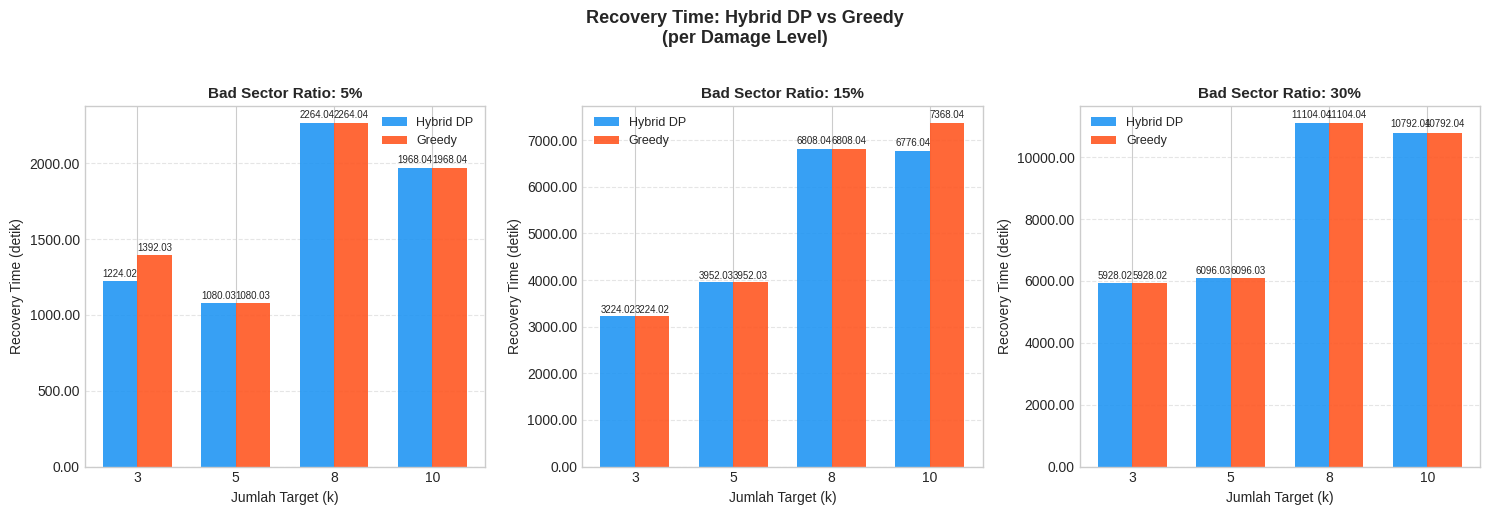

[✓] Plot 1 disimpan → results/figures/plot1_recovery_time.png


In [18]:
print('\n📊 Plot 1: Recovery Time DP vs Greedy per Damage Level...')
plot1_recovery_time(res1)

### Plot 2 — Skalabilitas CPU Time vs k

Line chart dengan dua sumbu-y:
- **Kiri:** CPU time DP (biru) dan Greedy (oranye) dalam milidetik
- **Kanan:** Jumlah DP states = k × 2^k (hijau, ribuan)

Grafik ini memperlihatkan trade-off antara **kualitas solusi** (DP, optimal) dan **biaya komputasi** yang tumbuh eksponensial.


In [19]:
# ================================================================
# PLOT 2: Skalabilitas CPU Time vs k
# ================================================================

def plot2_scalability(rows):
    """
    Line chart: CPU time DP & Greedy + jumlah DP States
    terhadap pertambahan jumlah target k.
    """
    k_vals = [int(r['k'])    for r in rows]
    dp_cpu = [r['dp_cpu_ms'] for r in rows]
    gr_cpu = [r['gr_cpu_ms'] for r in rows]
    states = [r['dp_states'] for r in rows]

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax2 = ax1.twinx()

    l1, = ax1.plot(k_vals, dp_cpu, 'o-',
                   color=COLOR_DP, lw=2.5, markersize=7,
                   label='DP CPU time (ms)')
    l2, = ax1.plot(k_vals, gr_cpu, 's--',
                   color=COLOR_GR, lw=2.5, markersize=7,
                   label='Greedy CPU time (ms)')
    l3, = ax2.plot(k_vals, [s / 1000 for s in states], '^:',
                   color=COLOR_ST, lw=2, markersize=7,
                   label='DP States (×10³)')

    # Anotasi nilai di setiap titik
    for kv, dp, gr in zip(k_vals, dp_cpu, gr_cpu):
        ax1.annotate(f'{dp:.2f}', (kv, dp),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=8, color=COLOR_DP)
        ax1.annotate(f'{gr:.3f}', (kv, gr),
                     textcoords='offset points', xytext=(0, -14),
                     ha='center', fontsize=8, color=COLOR_GR)

    ax1.set_xlabel('Jumlah Target (k)', fontsize=12)
    ax1.set_ylabel('CPU Time (ms)', fontsize=12)
    ax2.set_ylabel('Jumlah DP States (×10³)', fontsize=12, color=COLOR_ST)
    ax2.tick_params(axis='y', labelcolor=COLOR_ST)

    lines  = [l1, l2, l3]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', fontsize=10)
    ax1.set_title(
        'Skalabilitas Waktu Komputasi terhadap Jumlah Target (k)',
        fontsize=12, fontweight='bold'
    )
    ax1.grid(linestyle='--', alpha=0.5)
    ax1.set_xticks(k_vals)

    plt.tight_layout()
    path = 'results/figures/plot2_scalability.png'
    plt.savefig(path, dpi=DPI, bbox_inches='tight')
    plt.show()
    print(f'[✓] Plot 2 disimpan → {path}')


📊 Plot 2: Skalabilitas CPU Time vs k...


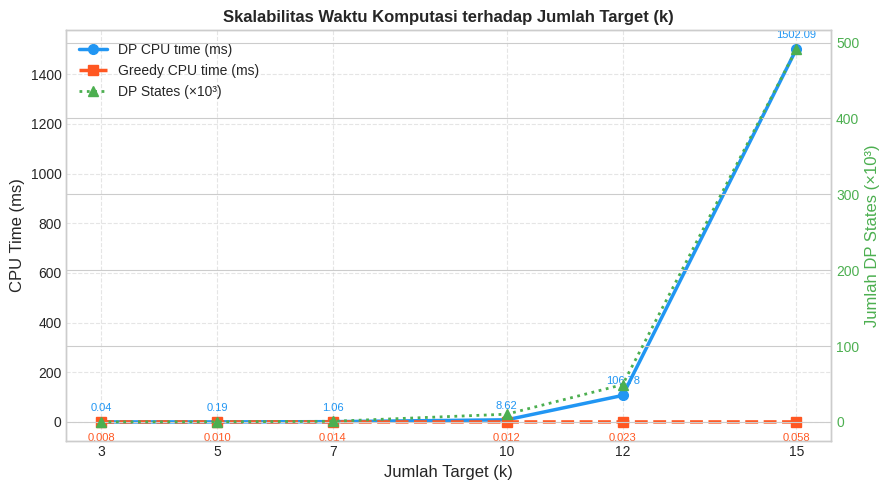

[✓] Plot 2 disimpan → results/figures/plot2_scalability.png


In [20]:
print('\n📊 Plot 2: Skalabilitas CPU Time vs k...')
plot2_scalability(res2)

### Plot 3 — Heatmap Improvement (%)

Heatmap 2D:
- **Sumbu X:** Jumlah target k
- **Sumbu Y:** Bad sector ratio

Nilai di setiap sel = `improvement_pct` DP vs Greedy. Warna **hijau tua** menunjukkan kondisi di mana DP paling menguntungkan dibanding Greedy.


In [21]:
# ================================================================
# PLOT 3: Heatmap Improvement %
# ================================================================

def plot3_heatmap(rows):
    """
    Heatmap: Improvement % DP vs Greedy
    sumbu X = jumlah target k
    sumbu Y = bad_ratio
    Hijau = DP lebih baik, Merah = Greedy lebih baik
    """
    bad_ratios = sorted(set(r['bad_ratio'] for r in rows))
    targets    = sorted(set(int(r['num_targets']) for r in rows))

    matrix = np.zeros((len(bad_ratios), len(targets)))
    for r in rows:
        i = bad_ratios.index(r['bad_ratio'])
        j = targets.index(int(r['num_targets']))
        matrix[i][j] = r['improvement_pct']

    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(matrix, cmap=CMAP_HEAT, aspect='auto', vmin=0)

    ax.set_xticks(range(len(targets)))
    ax.set_yticks(range(len(bad_ratios)))
    ax.set_xticklabels([str(t) for t in targets], fontsize=11)
    ax.set_yticklabels([f'{br:.0%}' for br in bad_ratios], fontsize=11)
    ax.set_xlabel('Jumlah Target (k)', fontsize=12)
    ax.set_ylabel('Bad Sector Ratio', fontsize=12)
    ax.set_title(
        'Improvement DP vs Greedy (%)\n(Hijau = DP lebih baik)',
        fontweight='bold', fontsize=12
    )

    # Anotasi nilai di setiap sel
    for i in range(len(bad_ratios)):
        for j in range(len(targets)):
            val       = matrix[i][j]
            txt_color = 'white' if val > 30 else 'black'
            ax.text(j, i, f'{val:.1f}%',
                    ha='center', va='center',
                    fontsize=11, fontweight='bold',
                    color=txt_color)

    plt.colorbar(im, ax=ax, label='Improvement (%)')
    plt.tight_layout()
    path = 'results/figures/plot3_improvement_heatmap.png'
    plt.savefig(path, dpi=DPI, bbox_inches='tight')
    plt.show()
    print(f'[✓] Plot 3 disimpan → {path}')


📊 Plot 3: Heatmap Improvement %...


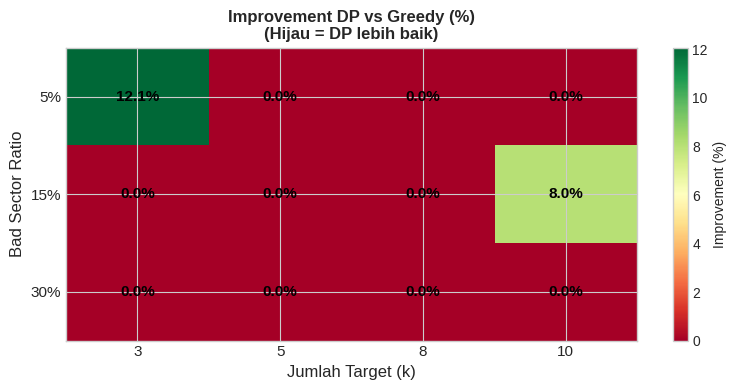

[✓] Plot 3 disimpan → results/figures/plot3_improvement_heatmap.png


In [22]:
print('\n📊 Plot 3: Heatmap Improvement %...')
plot3_heatmap(res1)

### Plot 4 — Recovery Time vs Bad Ratio

Dua subplot:
- **Atas:** Kurva recovery time DP dan Greedy sebagai fungsi bad_ratio, dengan area selisih diarsir abu-abu
- **Bawah:** Bar chart improvement (%) di setiap tingkat kerusakan


In [23]:
# ================================================================
# PLOT 4: Recovery Time vs Bad Ratio (Eksperimen 4)
# ================================================================

def plot4_recovery_vs_bad_ratio(rows):
    """
    Line chart: Recovery Time DP vs Greedy
    terhadap perubahan bad_ratio.
    """
    bad_ratios = [r['bad_ratio']     for r in rows]
    dp_vals    = [r['dp_recovery_s'] for r in rows]
    gr_vals    = [r['gr_recovery_s'] for r in rows]
    impr_vals  = [r['improvement_pct'] for r in rows]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

    # ── Subplot atas: Recovery Time ──────────────────────────
    ax1.plot(bad_ratios, dp_vals, 'o-',
             color=COLOR_DP, lw=2.5, markersize=7, label='Hybrid DP')
    ax1.plot(bad_ratios, gr_vals, 's--',
             color=COLOR_GR, lw=2.5, markersize=7, label='Greedy')
    ax1.fill_between(bad_ratios, dp_vals, gr_vals,
                     alpha=0.12, color='gray', label='Selisih')
    ax1.set_ylabel('Recovery Time (detik)', fontsize=11)
    ax1.set_title(
        'Recovery Time & Improvement vs Bad Sector Ratio',
        fontsize=12, fontweight='bold'
    )
    ax1.legend(fontsize=10)
    ax1.grid(linestyle='--', alpha=0.5)

    # Anotasi nilai
    for br, dp, gr in zip(bad_ratios, dp_vals, gr_vals):
        ax1.annotate(f'{dp:.2f}', (br, dp),
                     textcoords='offset points', xytext=(0, 7),
                     ha='center', fontsize=8, color=COLOR_DP)
        ax1.annotate(f'{gr:.2f}', (br, gr),
                     textcoords='offset points', xytext=(0, -14),
                     ha='center', fontsize=8, color=COLOR_GR)

    # ── Subplot bawah: Improvement % ────────────────────────
    bars = ax2.bar(
        [str(f'{br:.0%}') for br in bad_ratios],
        impr_vals,
        color=[COLOR_DP if v > 0 else COLOR_GR for v in impr_vals],
        alpha=0.85, edgecolor='white', linewidth=0.8
    )
    ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax2.set_xlabel('Bad Sector Ratio', fontsize=11)
    ax2.set_ylabel('Improvement DP vs Greedy (%)', fontsize=11)
    ax2.grid(axis='y', linestyle='--', alpha=0.5)

    # Anotasi nilai di atas bar
    for bar, val in zip(bars, impr_vals):
        ypos = bar.get_height() + 0.3 if val >= 0 else bar.get_height() - 1.5
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            ypos, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

    plt.tight_layout()
    path = 'results/figures/plot4_recovery_vs_bad_ratio.png'
    plt.savefig(path, dpi=DPI, bbox_inches='tight')
    plt.show()
    print(f'[✓] Plot 4 disimpan → {path}')


📊 Plot 4: Recovery Time vs Bad Ratio...


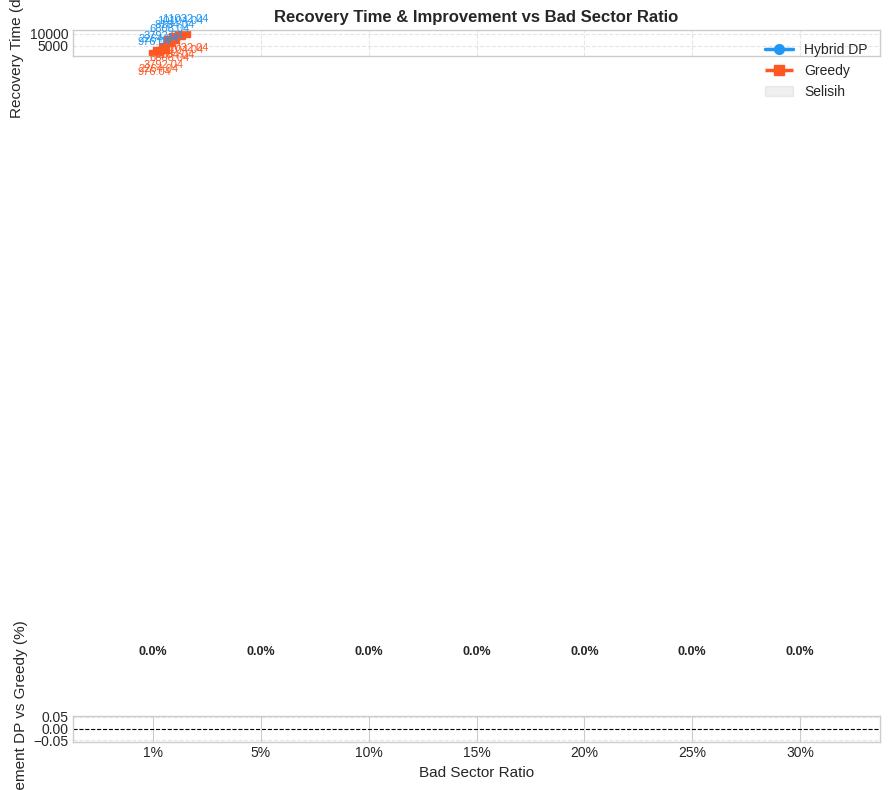

[✓] Plot 4 disimpan → results/figures/plot4_recovery_vs_bad_ratio.png


In [24]:
print('\n📊 Plot 4: Recovery Time vs Bad Ratio...')
plot4_recovery_vs_bad_ratio(res4)

### Plot 5 — Peta Visual Sektor HDD

Visualisasi posisi fisik sektor pada HDD (100 sektor) untuk Eksperimen 3:
- 🟥 **Merah** = bad sector
- 🟧 **Oranye** = posisi start head
- **Warna algoritma** = sektor target
- **Panah berlengkung** = urutan kunjungan (dengan nomor langkah)

Plot ini menunjukkan secara intuitif mengapa jalur DP lebih efisien: menghindari bolak-balik yang tidak perlu.


In [25]:
# ================================================================
# PLOT 5: Visualisasi Peta Sektor HDD (Eksperimen 3)
# ================================================================

def plot5_hdd_sector_map(res3_result):
    """
    Visualisasi posisi start, target, dan urutan kunjungan
    DP vs Greedy pada contoh konkret (Eksperimen 3).
    """
    cfg     = HDDConfig(num_sectors=100, bad_ratio=0.08,
                        cluster_prob=0.9, seed=13)
    hdd     = generate_logi(cfg)
    start   = 50
    targets = [1, 30, 70, 99]
    lba_dp  = res3_result['lba_dp']
    lba_gr  = res3_result['lba_gr']

    fig, axes = plt.subplots(2, 1, figsize=(14, 6))

    for ax, order, label, color, total in zip(
        axes,
        [lba_dp, lba_gr],
        ['Hybrid DP', 'Greedy Nearest'],
        [COLOR_DP, COLOR_GR],
        [res3_result['dp_min'], res3_result['gr_min']]
    ):
        # Gambar semua sektor
        for lba in range(cfg.num_sectors):
            if lba in hdd.bad_sectors:
                ax.barh(0, 1, left=lba, height=0.4,
                        color='#F44336', alpha=0.6)
            else:
                ax.barh(0, 1, left=lba, height=0.4,
                        color='#E0E0E0', alpha=0.4)

        # Gambar posisi start
        ax.barh(0, 1, left=start, height=0.5, color='#FF9800', alpha=1.0)
        ax.text(start, 0.35, 'S', ha='center', va='bottom', fontsize=9,
                fontweight='bold', color='#FF9800')

        # Gambar posisi target
        for t in targets:
            ax.barh(0, 1, left=t, height=0.5, color=color, alpha=0.9)
            ax.text(t, 0.35, str(t),
                    ha='center', va='bottom', fontsize=8,
                    fontweight='bold', color=color)

        # Gambar panah urutan kunjungan
        full_order = [start] + order
        for i in range(len(full_order) - 1):
            src = full_order[i]
            dst = full_order[i + 1]
            ax.annotate(
                '', xy=(dst + 0.5, 0),
                xytext=(src + 0.5, 0),
                arrowprops=dict(
                    arrowstyle='->', color=color,
                    lw=2.0, connectionstyle='arc3,rad=0.35'
                )
            )
            ax.text((src + dst) / 2 + 0.5, 0.22,
                    str(i + 1), ha='center', fontsize=8,
                    color=color, fontweight='bold')

        ax.set_xlim(-2, cfg.num_sectors + 2)
        ax.set_ylim(-0.5, 0.8)
        ax.set_xlabel('LBA (Logical Block Address)', fontsize=10)
        ax.set_title(
            f'{label}  →  Urutan: {order}  |  Total: {total:.4f} detik',
            fontsize=11, fontweight='bold', color=color
        )
        ax.set_yticks([])
        ax.grid(axis='x', linestyle='--', alpha=0.3)

    fig.suptitle(
        'Peta Sektor HDD: Urutan Kunjungan DP vs Greedy\n'
        '(🟥 Bad Sector | 🟧 Start | Warna = Target)',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    path = 'results/figures/plot5_hdd_sector_map.png'
    plt.savefig(path, dpi=DPI, bbox_inches='tight')
    plt.show()
    print(f'[✓] Plot 5 disimpan → {path}')


📊 Plot 5: Peta Sektor HDD (Eksperimen 3)...


/tmp/ipykernel_3411/3819303594.py:80: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3411/3819303594.py:80: UserWarning: Glyph 128999 (\N{LARGE ORANGE SQUARE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3411/3819303594.py:82: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) Liberation Sans.
  plt.savefig(path, dpi=DPI, bbox_inches='tight')
/tmp/ipykernel_3411/3819303594.py:82: UserWarning: Glyph 128999 (\N{LARGE ORANGE SQUARE}) missing from font(s) Liberation Sans.
  plt.savefig(path, dpi=DPI, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128999 (\N{LARGE ORANGE SQUARE}) missing from font(s) Libera

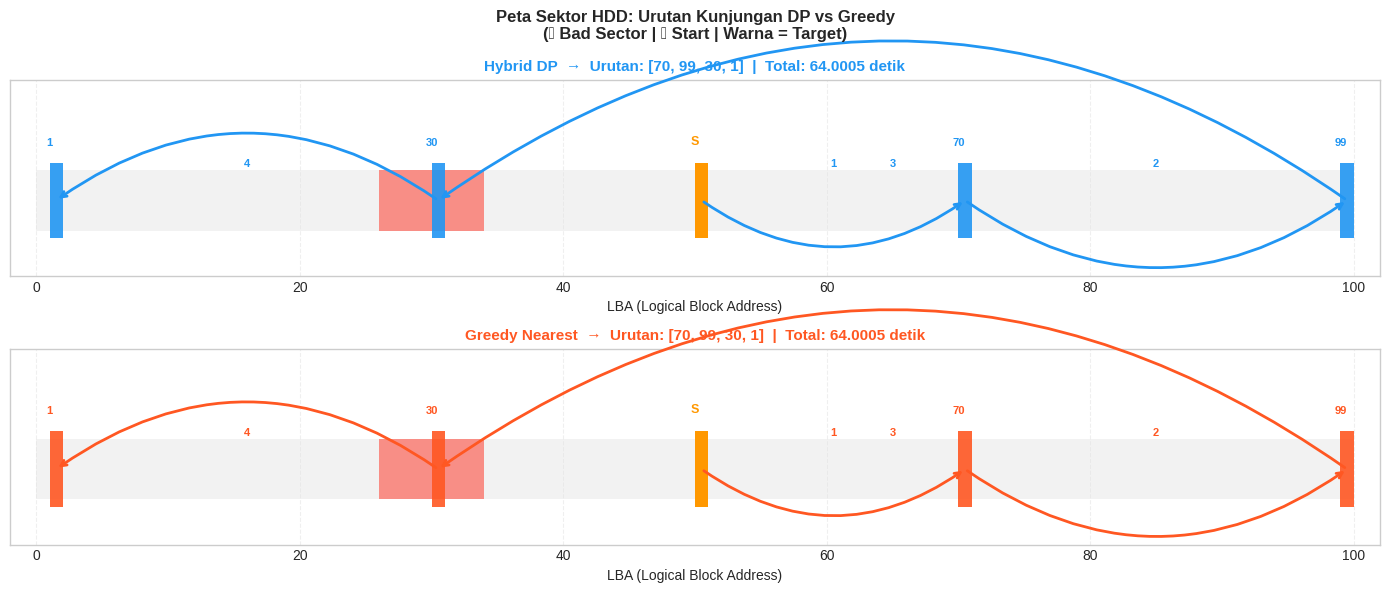

[✓] Plot 5 disimpan → results/figures/plot5_hdd_sector_map.png


In [26]:
print('\n📊 Plot 5: Peta Sektor HDD (Eksperimen 3)...')
plot5_hdd_sector_map(res3)

### Plot 6 — Dashboard Ringkasan (2×2)

Dashboard empat panel yang merangkum seluruh eksperimen dalam satu gambar:
1. **[atas kiri]** Rata-rata improvement per damage level (Exp 1)
2. **[atas kanan]** Pertumbuhan CPU time vs k (Exp 2)
3. **[bawah kiri]** Recovery time vs bad ratio (Exp 4)
4. **[bawah kanan]** Improvement % vs bad ratio (Exp 4)


In [27]:
# ================================================================
# PLOT 6: Ringkasan Perbandingan Semua Eksperimen
# ================================================================

def plot6_summary(res1, res2, res4):
    """
    Dashboard ringkasan 2x2:
    [1] Avg improvement per bad_ratio
    [2] DP CPU time growth
    [3] Recovery time exp4
    [4] Improvement exp4
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        'Dashboard Ringkasan: Hybrid DP vs Greedy\nHDD Recovery Optimization',
        fontsize=14, fontweight='bold'
    )

    # ── Panel [0,0]: Avg Improvement per bad_ratio (Exp1) ───
    ax = axes[0][0]
    bad_ratios_u = sorted(set(r['bad_ratio'] for r in res1))
    avg_impr = []
    for br in bad_ratios_u:
        vals = [r['improvement_pct'] for r in res1 if r['bad_ratio'] == br]
        avg_impr.append(np.mean(vals))

    bars = ax.bar(
        [f'{br:.0%}' for br in bad_ratios_u],
        avg_impr,
        color=[COLOR_DP if v > 0 else COLOR_GR for v in avg_impr],
        alpha=0.85, edgecolor='white'
    )
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title('Rata-rata Improvement per Damage Level\n(Eksperimen 1)',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Bad Sector Ratio')
    ax.set_ylabel('Avg Improvement (%)')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for bar, val in zip(bars, avg_impr):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f'{val:.1f}%',
            ha='center', fontsize=9, fontweight='bold'
        )

    # ── Panel [0,1]: DP CPU Time Growth (Exp2) ──────────────
    ax = axes[0][1]
    k_vals  = [int(r['k'])    for r in res2]
    dp_cpu  = [r['dp_cpu_ms'] for r in res2]
    gr_cpu  = [r['gr_cpu_ms'] for r in res2]
    ax.plot(k_vals, dp_cpu, 'o-', color=COLOR_DP, lw=2.5,
            markersize=7, label='DP')
    ax.plot(k_vals, gr_cpu, 's--', color=COLOR_GR, lw=2.5,
            markersize=7, label='Greedy')
    ax.set_title('Pertumbuhan CPU Time vs k\n(Eksperimen 2)',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Jumlah Target (k)')
    ax.set_ylabel('CPU Time (ms)')
    ax.legend(fontsize=9)
    ax.set_xticks(k_vals)
    ax.grid(linestyle='--', alpha=0.5)
    for kv, dp in zip(k_vals, dp_cpu):
        ax.annotate(f'{dp:.1f}', (kv, dp),
                    textcoords='offset points', xytext=(0, 7),
                    ha='center', fontsize=8, color=COLOR_DP)

    # ── Panel [1,0]: Recovery Time vs Bad Ratio (Exp4) ──────
    ax = axes[1][0]
    br4  = [r['bad_ratio']     for r in res4]
    dp4  = [r['dp_recovery_s'] for r in res4]
    gr4  = [r['gr_recovery_s'] for r in res4]
    ax.plot(br4, dp4, 'o-', color=COLOR_DP, lw=2.5,
            markersize=7, label='Hybrid DP')
    ax.plot(br4, gr4, 's--', color=COLOR_GR, lw=2.5,
            markersize=7, label='Greedy')
    ax.fill_between(br4, dp4, gr4, alpha=0.12, color='gray')
    ax.set_title('Recovery Time vs Bad Ratio\n(Eksperimen 4)',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Bad Sector Ratio')
    ax.set_ylabel('Recovery Time (detik)')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
    ax.grid(linestyle='--', alpha=0.5)

    # ── Panel [1,1]: Improvement % vs Bad Ratio (Exp4) ──────
    ax = axes[1][1]
    impr4 = [r['improvement_pct'] for r in res4]
    ax.plot(br4, impr4, 'D-', color='#9C27B0', lw=2.5,
            markersize=7, label='Improvement %')
    ax.fill_between(br4, 0, impr4,
                    alpha=0.15, color='#9C27B0')
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title('Improvement DP vs Greedy (%)\n(Eksperimen 4)',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Bad Sector Ratio')
    ax.set_ylabel('Improvement (%)')
    ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
    ax.grid(linestyle='--', alpha=0.5)
    for br, imp in zip(br4, impr4):
        ax.annotate(f'{imp:.1f}%', (br, imp),
                    textcoords='offset points', xytext=(0, 7),
                    ha='center', fontsize=8, color='#9C27B0')

    plt.tight_layout()
    path = 'results/figures/plot6_summary_dashboard.png'
    plt.savefig(path, dpi=DPI, bbox_inches='tight')
    plt.show()
    print(f'[✓] Plot 6 disimpan → {path}')


📊 Plot 6: Dashboard Ringkasan...


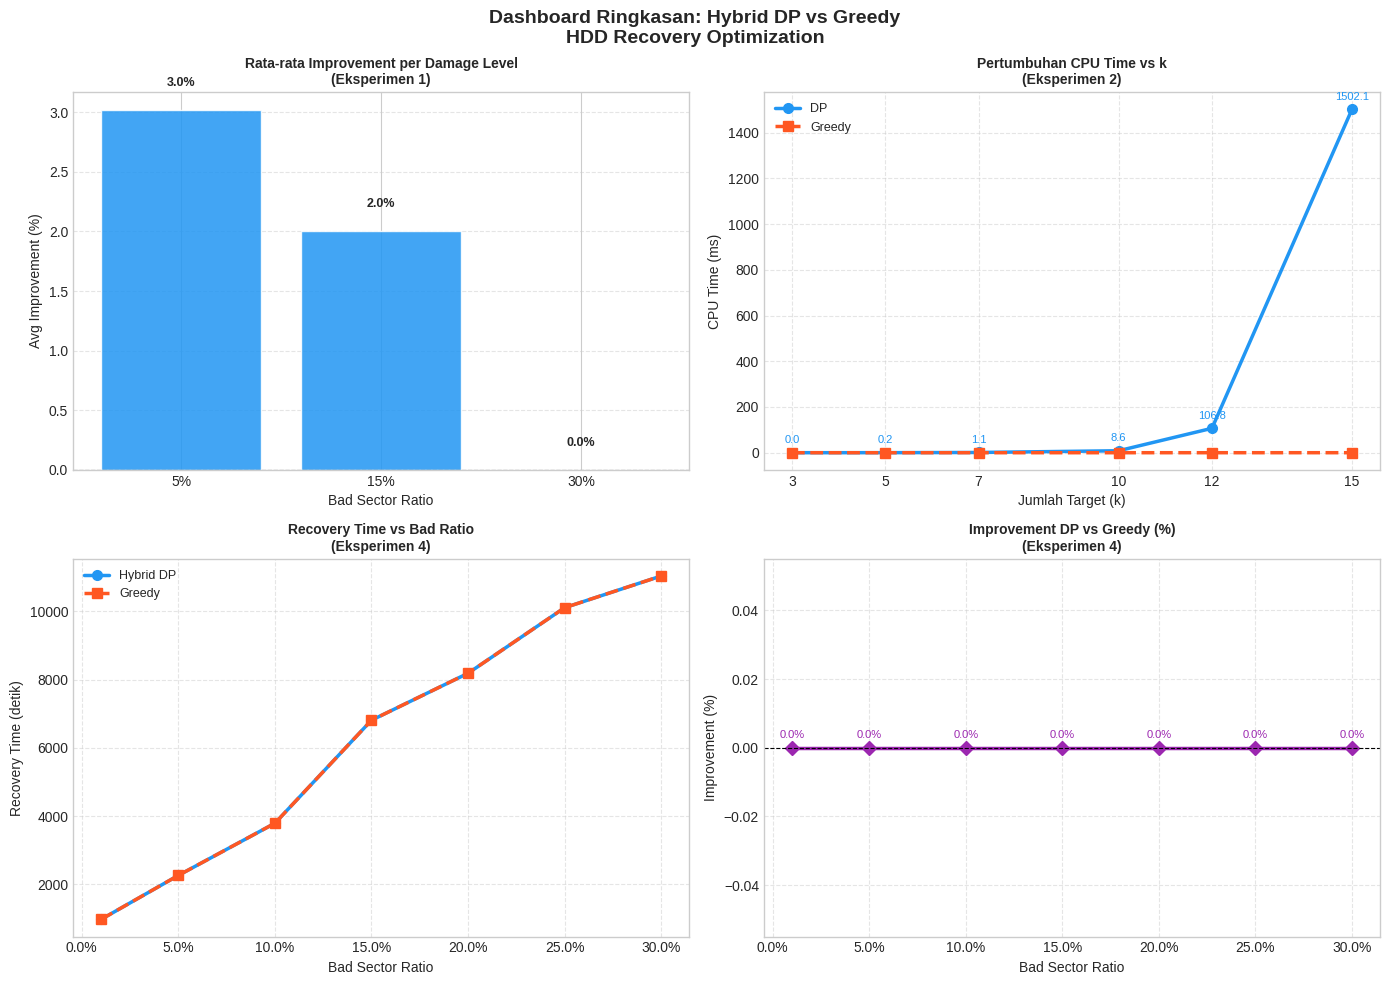

[✓] Plot 6 disimpan → results/figures/plot6_summary_dashboard.png


In [28]:
print('\n📊 Plot 6: Dashboard Ringkasan...')
plot6_summary(res1, res2, res4)

---
## 📊 Ringkasan & Kesimpulan

### Temuan yang Diharapkan

1. **DP selalu memberikan solusi optimal** — improvement ≥ 0% di semua skenario karena Held-Karp menjamin solusi exact.

2. **Improvement DP paling signifikan pada:**
   - Bad ratio **tinggi** (banyak penalti, jalur alternatif lebih kritis)
   - k **besar** (ruang keputusan lebih luas, Greedy lebih sering sub-optimal)

3. **Waktu komputasi DP tumbuh eksponensial** terhadap k — ada batas praktis di sekitar k ≤ 15–18 untuk lingkungan nyata.

4. **Greedy tetap relevan** untuk k besar atau skenario di mana latensi komputasi lebih kritis dari optimalitas rute.

### Panduan Penggunaan

| Kondisi | Rekomendasi |
|---------|-------------|
| k ≤ 12, bad_ratio tinggi | Gunakan Hybrid DP |
| k > 15, real-time | Gunakan Greedy atau heuristik lain |
| HDD hampir mulus (bad_ratio < 5%) | Kedua algoritma hampir ekuivalen |

---
*Notebook ini menggunakan seed deterministik (`seed=42`) agar hasil dapat direproduksi secara konsisten.*


In [29]:
# ================================================================
# RINGKASAN AKHIR
# ================================================================

print('\n' + '='*65)
print('  RINGKASAN HASIL EKSPERIMEN')
print('='*65)

# Statistik Eksperimen 1
all_impr  = [r['improvement_pct'] for r in res1]
best_res  = max(res1, key=lambda r: r['improvement_pct'])
worst_res = min(res1, key=lambda r: r['improvement_pct'])

print(f'\n📌 Eksperimen 1 (Damage × Target):')
print(f'   Rata-rata improvement : {np.mean(all_impr):.2f}%')
print(f'   Improvement tertinggi : {best_res["improvement_pct"]:.2f}%'
      f' (bad={best_res["bad_ratio"]:.0%}, k={int(best_res["num_targets"])})')
print(f'   Improvement terendah  : {worst_res["improvement_pct"]:.2f}%'
      f' (bad={worst_res["bad_ratio"]:.0%}, k={int(worst_res["num_targets"])})')

# Statistik Eksperimen 2
max_dp_cpu = max(res2, key=lambda r: r['dp_cpu_ms'])
print(f'\n📌 Eksperimen 2 (Skalabilitas):')
print(f'   CPU time DP tertinggi : {max_dp_cpu["dp_cpu_ms"]:.3f} ms'
      f' (k={int(max_dp_cpu["k"])})')
print(f'   DP States terbanyak   : {max_dp_cpu["dp_states"]:,}')

# Statistik Eksperimen 3
print(f'\n📌 Eksperimen 3 (Contoh Konkret):')
print(f'   DP  : {res3["dp_min"]:.4f} detik  →  {res3["lba_dp"]}')
print(f'   Greedy: {res3["gr_min"]:.4f} detik  →  {res3["lba_gr"]}')
print(f'   Improvement: {res3["improvement"]:.2f}%')

# Statistik Eksperimen 4
avg_impr4 = np.mean([r['improvement_pct'] for r in res4])
print(f'\n📌 Eksperimen 4 (Recovery vs Bad Ratio):')
print(f'   Rata-rata improvement : {avg_impr4:.2f}%')
print(f'   Range bad ratio       : '
      f'{min(r["bad_ratio"] for r in res4):.0%} – '
      f'{max(r["bad_ratio"] for r in res4):.0%}')

print('\n' + '='*65)
print('✅ SEMUA EKSPERIMEN & VISUALISASI SELESAI!')
print(f'   Plot tersimpan di: results/figures/')
print(f'   CSV  tersimpan di: results/')
print('='*65)


  RINGKASAN HASIL EKSPERIMEN

📌 Eksperimen 1 (Damage × Target):
   Rata-rata improvement : 1.68%
   Improvement tertinggi : 12.07% (bad=5%, k=3)
   Improvement terendah  : 0.00% (bad=5%, k=5)

📌 Eksperimen 2 (Skalabilitas):
   CPU time DP tertinggi : 1502.091 ms (k=15)
   DP States terbanyak   : 491,520

📌 Eksperimen 3 (Contoh Konkret):
   DP  : 64.0005 detik  →  [70, 99, 30, 1]
   Greedy: 64.0005 detik  →  [70, 99, 30, 1]
   Improvement: 0.00%

📌 Eksperimen 4 (Recovery vs Bad Ratio):
   Rata-rata improvement : 0.00%
   Range bad ratio       : 1% – 30%

✅ SEMUA EKSPERIMEN & VISUALISASI SELESAI!
   Plot tersimpan di: results/figures/
   CSV  tersimpan di: results/
